In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pl
import sns

from sklearn import metrics
from sklearn import tree
from sklearn.datasets import load_iris, load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

#Decision Tree Classifier

In [5]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns = iris.feature_names)

df['Species'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
target = np.unique(iris.target)
target_names = np.unique(iris.target_names)

targets = dict(zip(target, target_names))

df['Species'] = df['Species'].replace(targets)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
x = df.drop(columns="Species")
y = df["Species"]

feature_names = x.columns
labels = y.unique()

X_train, X_test, y_train, y_test = train_test_split(x, y,
                                                 test_size = 0.4,
                                                 random_state = 42)

In [8]:
clf = DecisionTreeClassifier(max_depth = 3, random_state = 42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [9]:
text_representation = tree.export_text(clf)
print(text_representation)

|--- feature_2 <= 2.45
|   |--- class: setosa
|--- feature_2 >  2.45
|   |--- feature_3 <= 1.75
|   |   |--- feature_2 <= 5.35
|   |   |   |--- class: versicolor
|   |   |--- feature_2 >  5.35
|   |   |   |--- class: virginica
|   |--- feature_3 >  1.75
|   |   |--- feature_2 <= 4.85
|   |   |   |--- class: virginica
|   |   |--- feature_2 >  4.85
|   |   |   |--- class: virginica



In [10]:
%matplotlib inline

In [11]:
%config InlineBackend.figure_format = 'png'

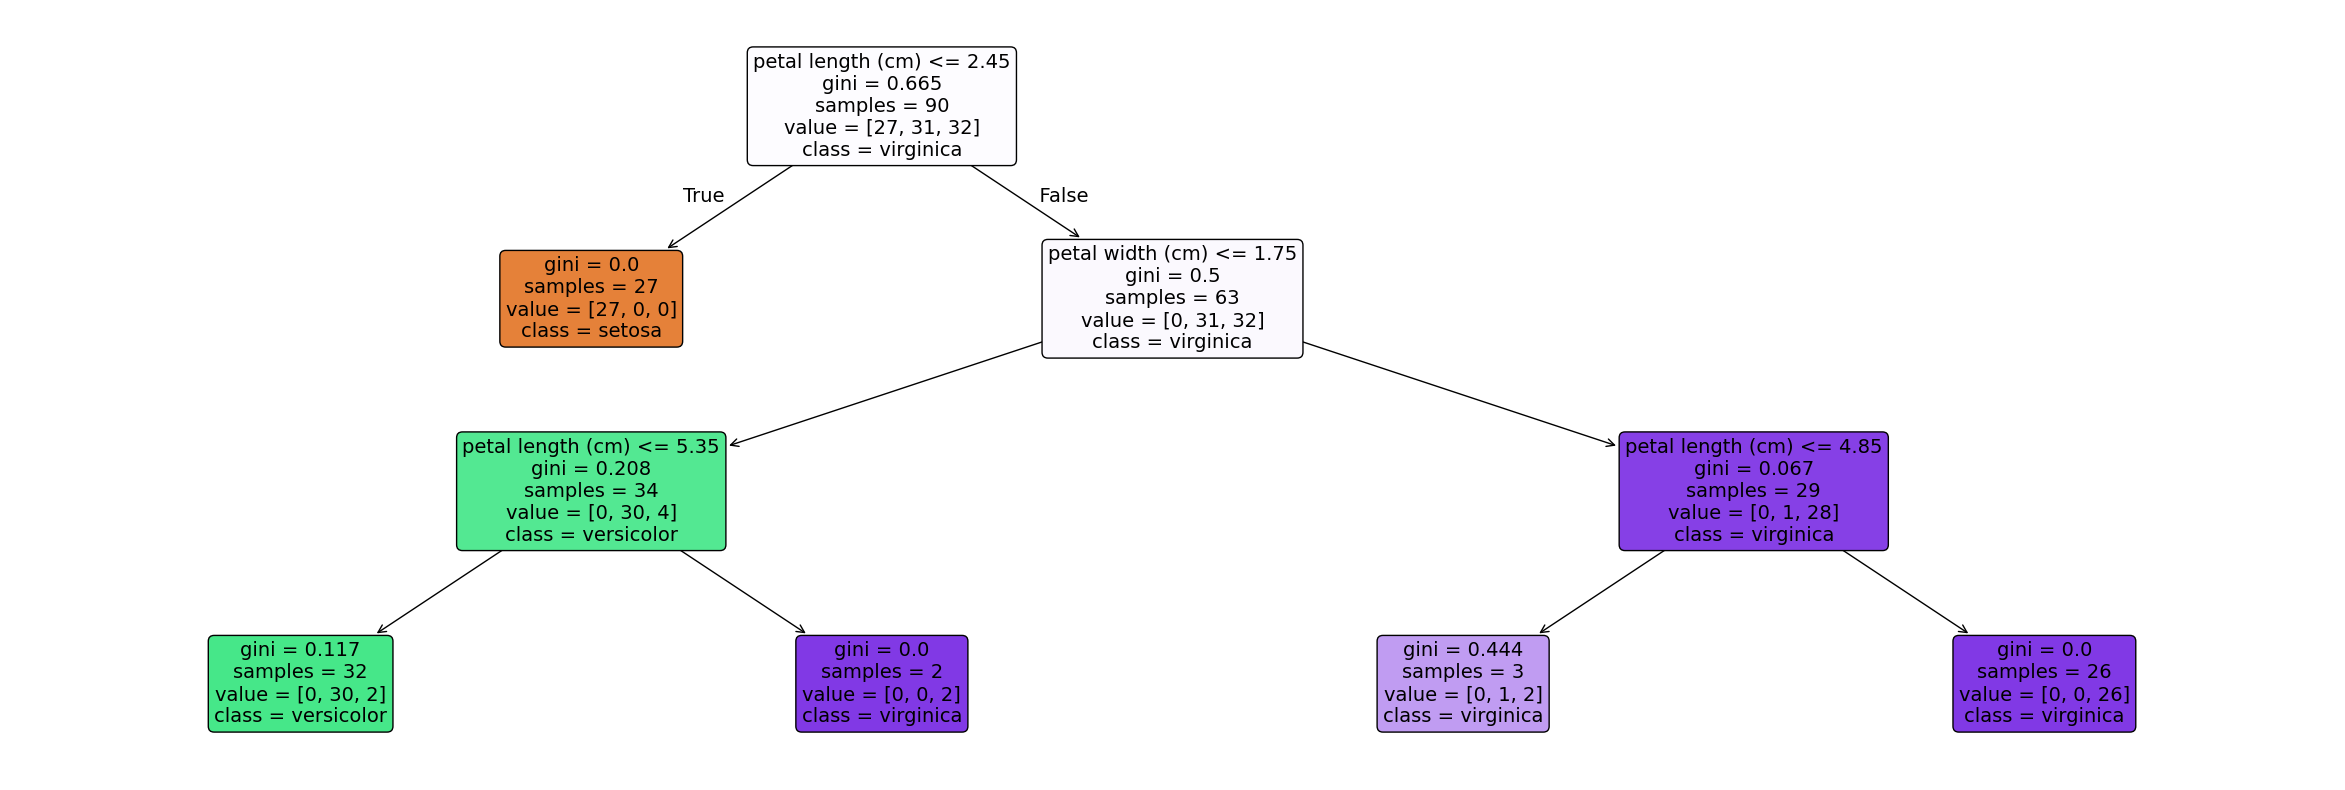

In [12]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(30,10))
a = tree.plot_tree(clf,
                   feature_names = feature_names,
                   class_names = labels,
                   rounded = True, filled = True, fontsize=14)

The first split is made based on the value of the petal_length attribute, where flowers with a length less than or equal to 2.45 cm are classified as "setosa" (the left branch of the tree). We can observe that there are 27 training samples (all from the same class), which is why the Gini index is 0 (meaning the node impurity is 0).
In the right branch, there are 63 samples, of which 32 belong to the "virginica" class and 31 to the "versicolor" class. Since there is a relatively balanced distribution between these two remaining classes, the Gini index is approximately 0.5. Because of this, for this node where plants have petal length greater than 2.45 cm, additional splitting occurs, followed by two more splits to achieve more precise final classifications.
We can observe that in the remaining leaves, from left to right, the Gini indices are: 0.117, 0, 0.444, and 0. As we can see, two of these leaves have pure classification (Gini index is 0), but in the other two (the first and third from left to right), the classification is not pure. The reason why these branches do not continue to split is because we set the maximum depth of the tree to 3. Similar behavior can be achieved by changing the tree parameters min_samples_split and min_samples_leaf. These prevent further division if there aren't enough samples in order to prevent overfitting of the tree.
Here, we're not only interested in how well the classifier handles the training data, but also how well it functions on unseen test data. This means we'll need to use the decision tree to predict the class based on test data, which we'll do with the predict() method.


In [13]:
test_pred_decision_tree = clf.predict(X_test)
print("First five predictions: ", test_pred_decision_tree[:5])

First five predictions:  [np.str_('versicolor') np.str_('setosa') np.str_('virginica')
 np.str_('versicolor') np.str_('versicolor')]


NameError: name 'sns' is not defined

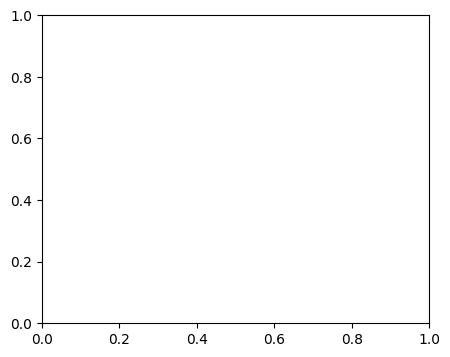

In [16]:
fig = plt.figure(figsize=(5,4))
ax = plt.axes()

confusion_matrix = metrics.confusion_matrix(y_test, test_pred_decision_tree)
matrix_df = pd.DataFrame(confusion_matrix)

sns.set(font_scale=1)

sns.heatmap(matrix_df, annot=True, fmt="g", ax=ax, cmap="Blues")

ax.set_title('Confusion matrix')
ax.set_xlabel("Predicted label", fontsize =14)
ax.set_xticklabels(['']+labels)
ax.set_ylabel("True label", fontsize=14)

ax.set_yticklabels(list(labels), rotation = 0)
plt.show()

## Decision Boundaries

C:\Users\Sandra\AppData\Local\Temp\ipykernel_8976\3780639671.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
C:\Users\Sandra\AppData\Local\Temp\ipykernel_8976\3780639671.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
C:\Users\Sandra\AppData\Local\Temp\ipykernel_8976\3780639671.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
C:\Users\Sandra\AppData\Local\Temp\ipykernel_8976\3780639671.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
C:\Users\Sandra\AppData\Local\Temp\ipykernel_8976\3780639671.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
C:\Users\Sandra\AppData\Local\Temp\ipykernel_8976\3780639671.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 

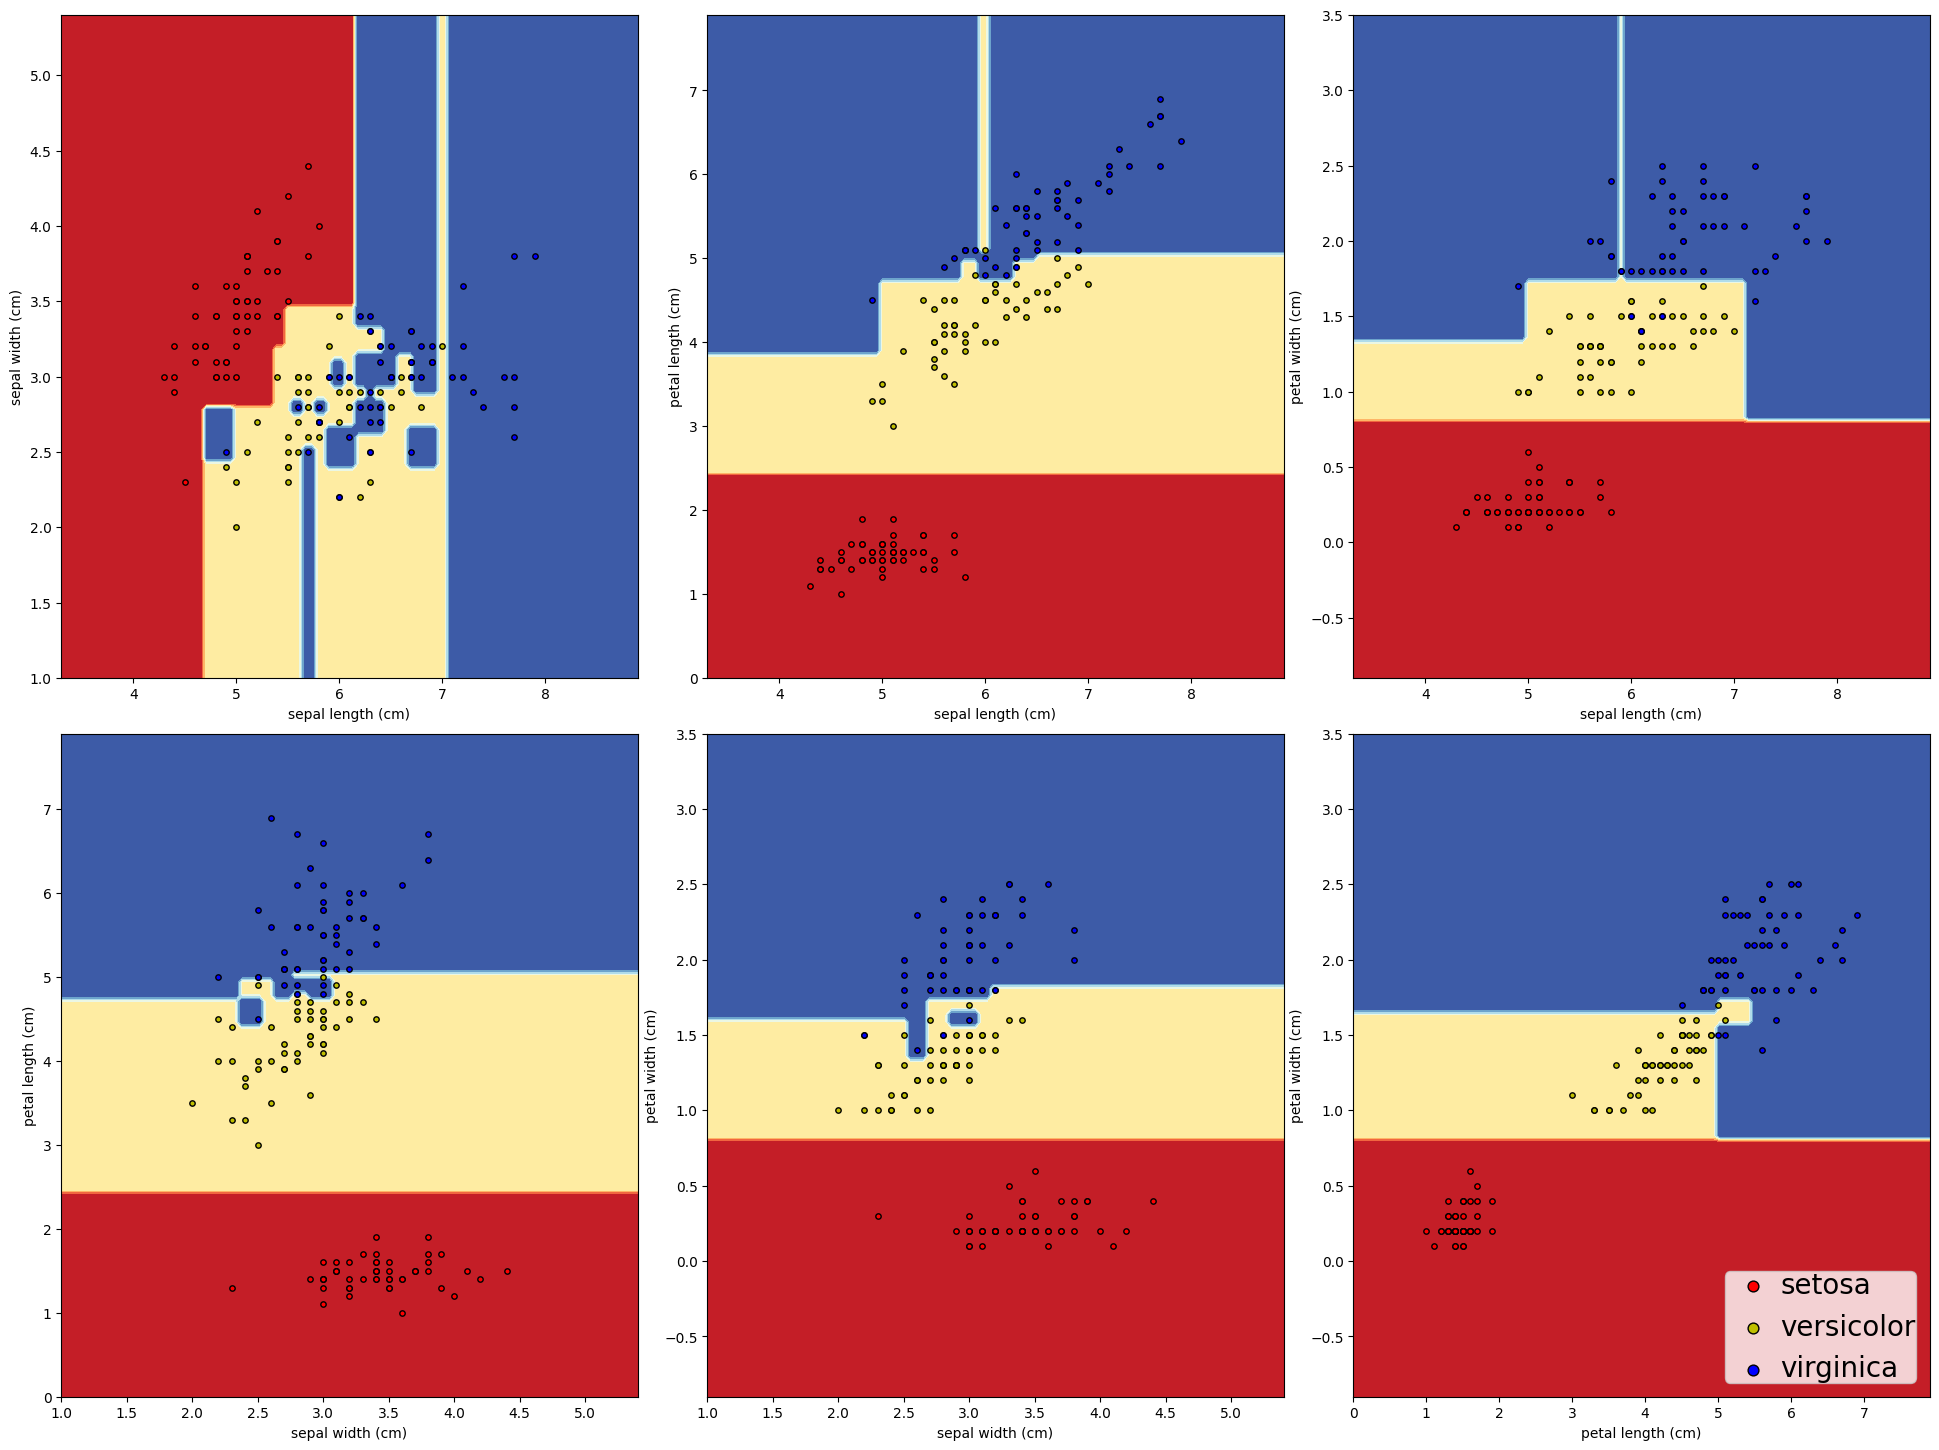

In [17]:
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02
fig = plt.figure(figsize=(20,15))

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    X = iris.data[:, pair]
    y = iris.target

    clf = DecisionTreeClassifier().fit(X, y)

    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=iris.feature_names[pair[0]],
        ylabel=iris.feature_names[pair[1]],
    )

    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=iris.target_names[i],
            cmap=plt.cm.RdYlBu,
            edgecolor="black",
            s=15,
        )

plt.legend(loc="lower right", borderpad=0, handletextpad=0, markerscale=2., scatterpoints=1, fontsize=20)
_ = plt.axis("tight")

In [18]:
dtree = DecisionTreeClassifier(criterion='gini')
dtree.fit(X_train, y_train)
pred = dtree.predict(X_test)
print('criterion=gini accuracy:', accuracy_score(y_test, pred))

dtree = DecisionTreeClassifier(criterion='entropy')
dtree.fit(X_train, y_train)
pred = dtree.predict(X_test)
print('criterion=entropy accuracy:', accuracy_score(y_test, pred))

criterion=gini accuracy: 0.9833333333333333
criterion=entropy accuracy: 0.9833333333333333


In [19]:
max_depth = []
acc_gini = []
acc_entropy = []

y_test_np=y_test.to_numpy()
for i in range(1,30):
    dtree = DecisionTreeClassifier(criterion='gini', max_depth=i)
    dtree.fit(X_train, y_train)
    pred = dtree.predict(X_test)
    acc_gini.append(accuracy_score(y_test_np, pred))

    dtree = DecisionTreeClassifier(criterion='entropy', max_depth=i)
    dtree.fit(X_train, y_train)
    pred = dtree.predict(X_test)
    acc_entropy.append(accuracy_score(y_test_np, pred))

    max_depth.append(i)

df = pd.DataFrame([acc_gini, acc_entropy, max_depth]).transpose()
df.columns=['acc_gini', 'acc_entropy', 'max_depth']
df.head(10)

,acc_gini,acc_entropy,max_depth
0,0.683333,0.683333,1.0
1,0.983333,0.983333,2.0
2,0.983333,0.983333,3.0
3,0.983333,0.983333,4.0
4,0.983333,0.966667,5.0
5,1.000000,0.983333,6.0
6,0.966667,0.983333,7.0
7,0.983333,0.983333,8.0
8,0.966667,0.983333,9.0
9,0.966667,0.983333,10.0


Text(0, 0.5, 'accuracy')

<Figure size 1280x960 with 0 Axes>

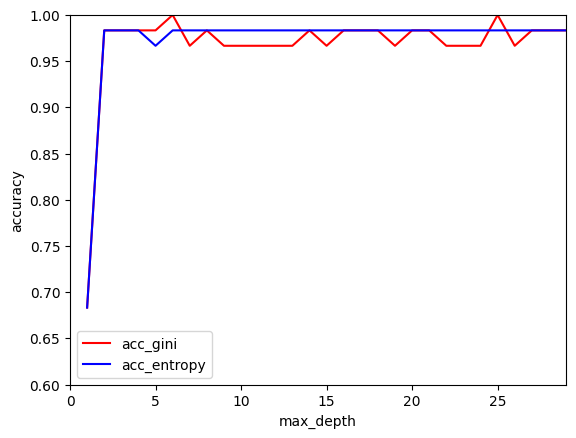

In [20]:
fig=plt.figure(dpi= 200, facecolor='w', edgecolor='k')

df.plot.line(x='max_depth', color={"acc_gini": "red", "acc_entropy": "blue"})
plt.xlim(0, max_depth[-1])
plt.ylim(0.6, 1)
plt.ylabel('accuracy')


From this graph, it can be observed that in this example, when using entropy, we have stable accuracy that does not change depending on the depth of the tree. In some cases, identical performance is achieved when using the Gini index, but this is not consistently stable. For practical reasons (for better explainability and better generalization to unseen samples), shallower trees are usually preferred. In this case, it can be observed that with a depth of 6 for the entropy splitting criterion, the maximum accuracy of 0.983333 is achieved.


##Breast Cancer Dataset

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
clf = DecisionTreeClassifier()

In [22]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
path

{'ccp_alphas': array([0.        , 0.00226647, 0.00464743, 0.0046598 , 0.0056338 ,
        0.00704225, 0.00784194, 0.00911402, 0.01144366, 0.018988  ,
        0.02314163, 0.03422475, 0.32729844]),
 'impurities': array([0.        , 0.00453294, 0.01847522, 0.02313502, 0.02876883,
        0.03581108, 0.04365302, 0.05276704, 0.0642107 , 0.0831987 ,
        0.10634033, 0.14056508, 0.46786352])}

This code calculates the optimal pruning parameters for our decision tree using the cost_complexity_pruning_path method, which implements minimal cost-complexity pruning.

The function returns a dictionary containing:

1. 'ccp_alphas': An array of alpha values, each representing a different pruning threshold.
- Alpha = 0 means no pruning (the full tree)
- Higher alpha values result in more aggressive pruning
- Each alpha value corresponds to a different optimal subtree
- The largest value (0.32729844) would produce just the root node (most severe pruning)

2. 'impurities': The total impurity of the tree at each corresponding alpha value.
- As alpha increases, impurity also increases because the tree becomes simpler
- This represents the trade-off between model complexity and training accuracy

These values help us identify the optimal pruning level by allowing us to create multiple trees with different complexity levels and evaluate their performance on validation data.

Text(0, 0.5, 'Total impurity of leaves')

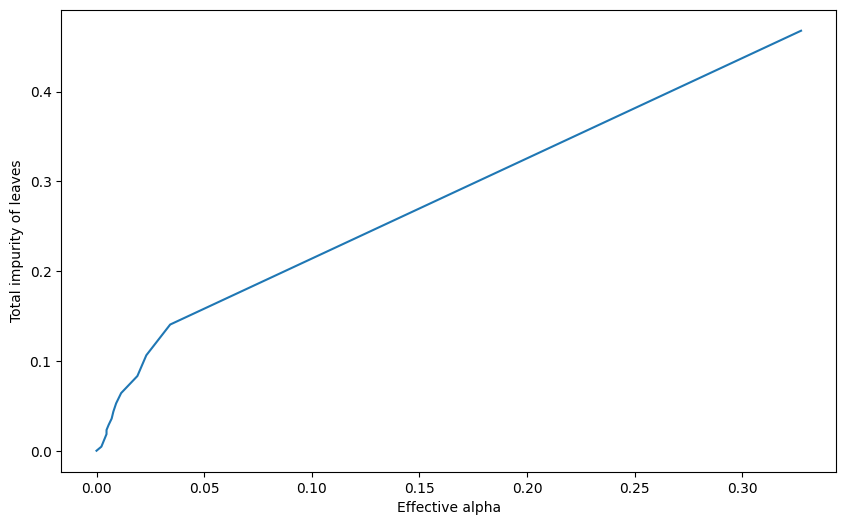

In [23]:
ccp_alphas, impurities = path.ccp_alphas, path.impurities

plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, impurities)
plt.xlabel("Effective alpha")
plt.ylabel("Total impurity of leaves")

In [24]:
clfs = []

for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

Text(0, 0.5, 'Total depth')

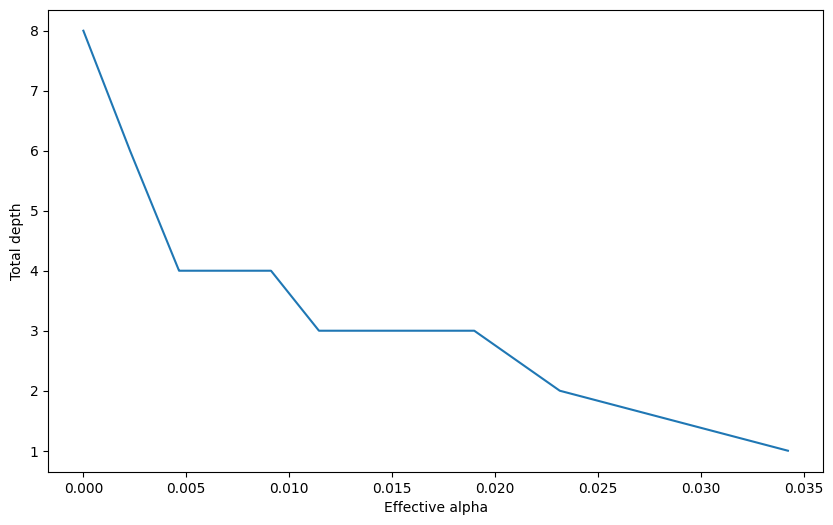

In [25]:
tree_depths = [clf.tree_.max_depth for clf in clfs]
plt.figure(figsize=(10,  6))
plt.plot(ccp_alphas[:-1], tree_depths[:-1])
plt.xlabel("Effective alpha")
plt.ylabel("Total depth")

In [26]:
acc_scores = [accuracy_score(y_test, clf.predict(X_test)) for clf in clfs]

tree_depths = [clf.tree_.max_depth for clf in clfs]

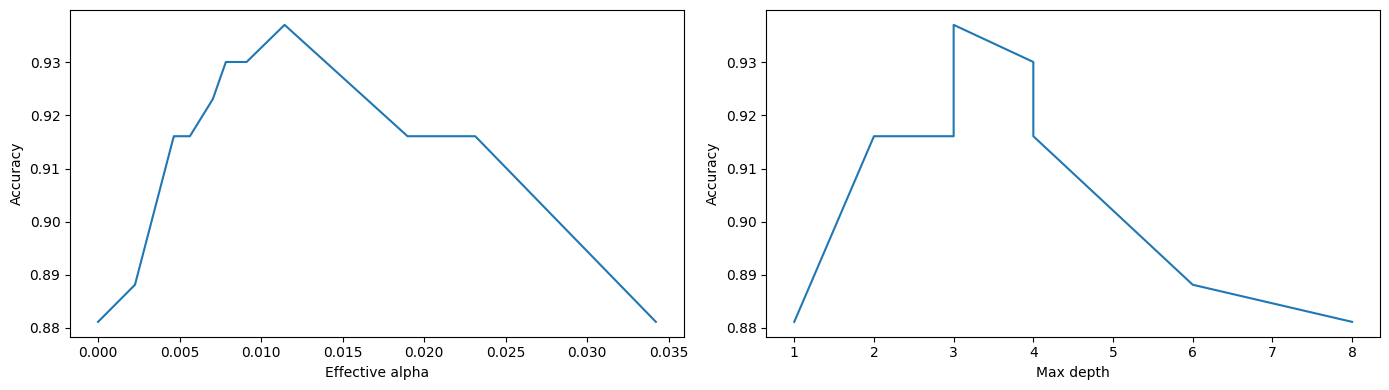

In [27]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))  # 'fig' is the whole figure, 'axs' is an array with your subplots

axs[0].plot(ccp_alphas[:-1], acc_scores[:-1])
axs[0].set_xlabel("Effective alpha")
axs[0].set_ylabel('Accuracy')

axs[1].plot(tree_depths[:-1], acc_scores[:-1])
axs[1].set_xlabel("Max depth")
axs[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

# Decision Tree Regressor



##California Housing Dataset

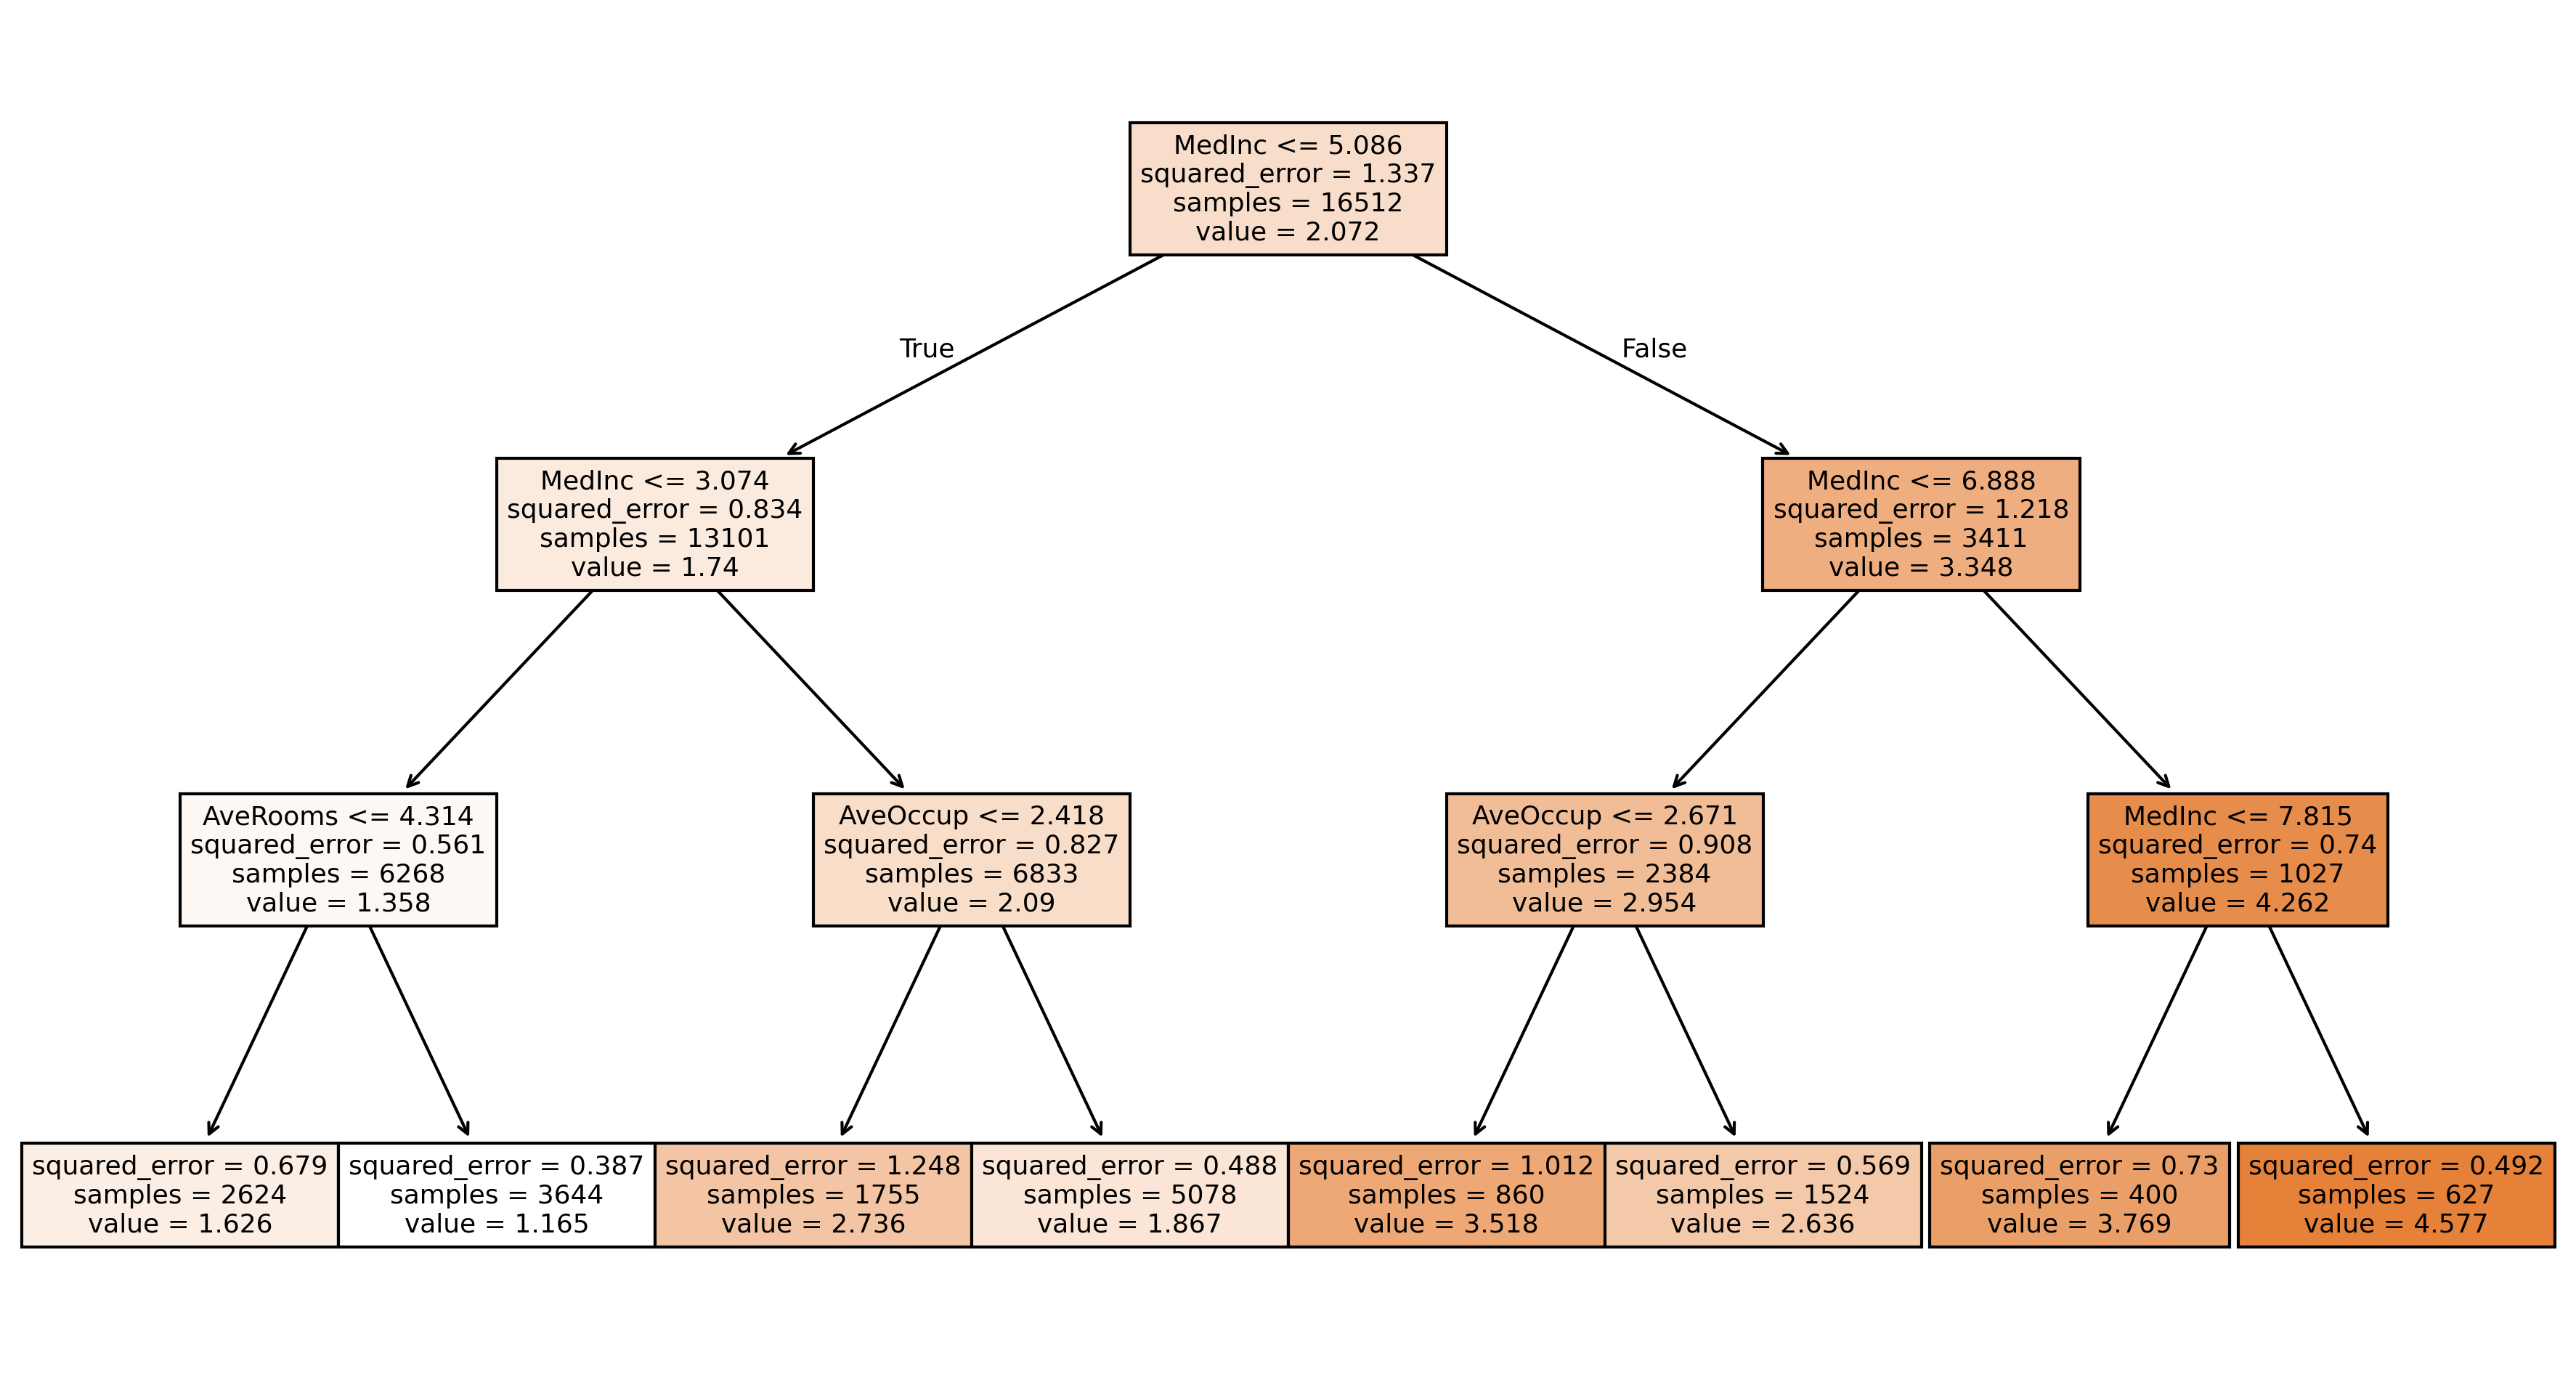

Mean Squared Error - MSE: 0.6424109810265641
Mean Absolute Error - MAE: 0.5978280732432436
R^2 Score: 0.5097629887358219


In [28]:
data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = DecisionTreeRegressor(max_depth=3, random_state=42)
regressor.fit(X_train, y_train)

plt.figure(figsize=(15, 8), dpi=300)
plot_tree(regressor, filled=True, feature_names=data.feature_names)
plt.show()

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error - MSE: {mse}")
print(f"Mean Absolute Error - MAE: {mae}")
print(f"R^2 Score: {r2}")

At the root level the split is made according to the attribute MedInc (median income), which is a continuous variable. The split is based on MedInc <= 5.086, so instances for which this is true go to the left branch, and the rest go to the right branch. Furthermore, both the left and right nodes are again split according to the same attribute, just with different thresholds (3.074 and 6.888, respectively). Similar to classification trees, each node shows how many samples it contains (the value 'samples'), but also what value would be predicted at that node. Of course, the prediction is made at the leaves. In fact, as we move from the root toward a leaf, the nodes become purer, and because of this, the value of the squared_error parameter decreases and the prediction becomes more precise.


#Random Forest Classifier

##Breast Cancer Dataset


In [29]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

X = df.loc[:, df.columns != 'target']
y = df.lclassifieroc[:, 'target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

rf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

AttributeError: 'DataFrame' object has no attribute 'lclassifieroc'

NameError: name 'rf' is not defined

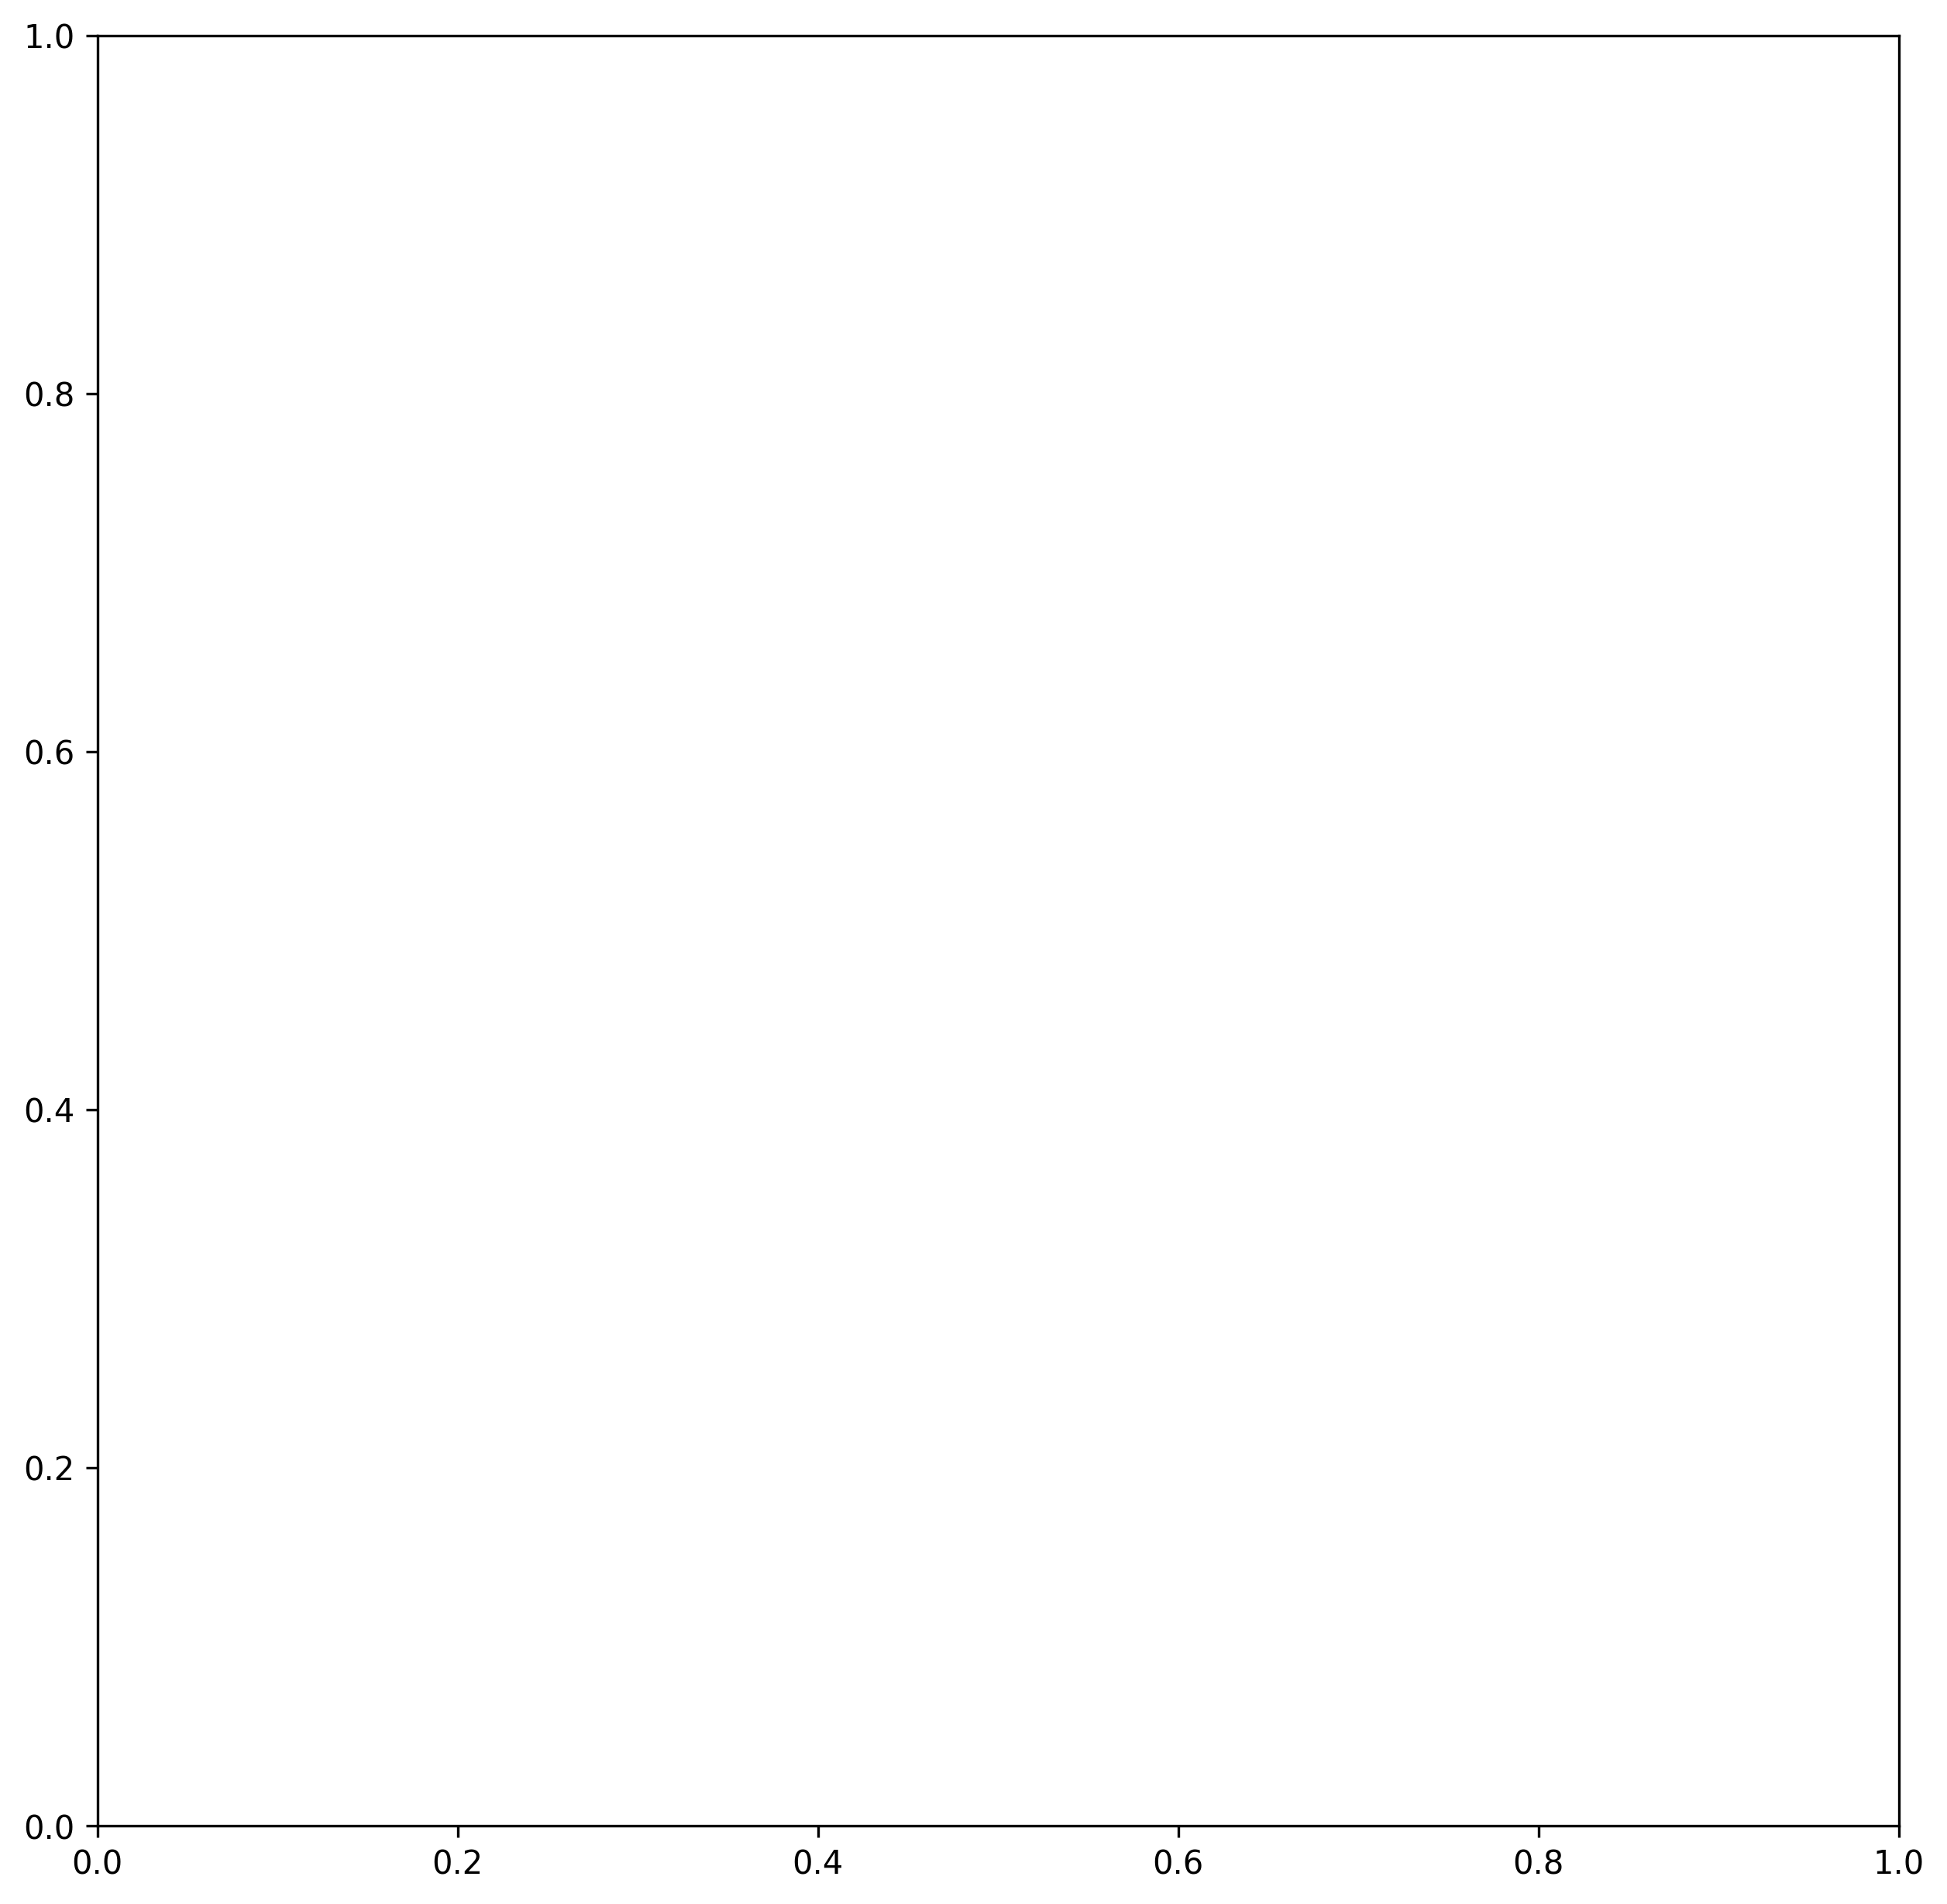

In [30]:
fn=data.feature_names
cn=data.target_names

fig, axes = plt.subplots(nrows = 1, ncols = 1,figsize = (10, 10), dpi=300)

#first tree
tree.plot_tree(rf.estimators_[0], feature_names = fn, class_names=cn, filled = True);

NameError: name 'rf' is not defined

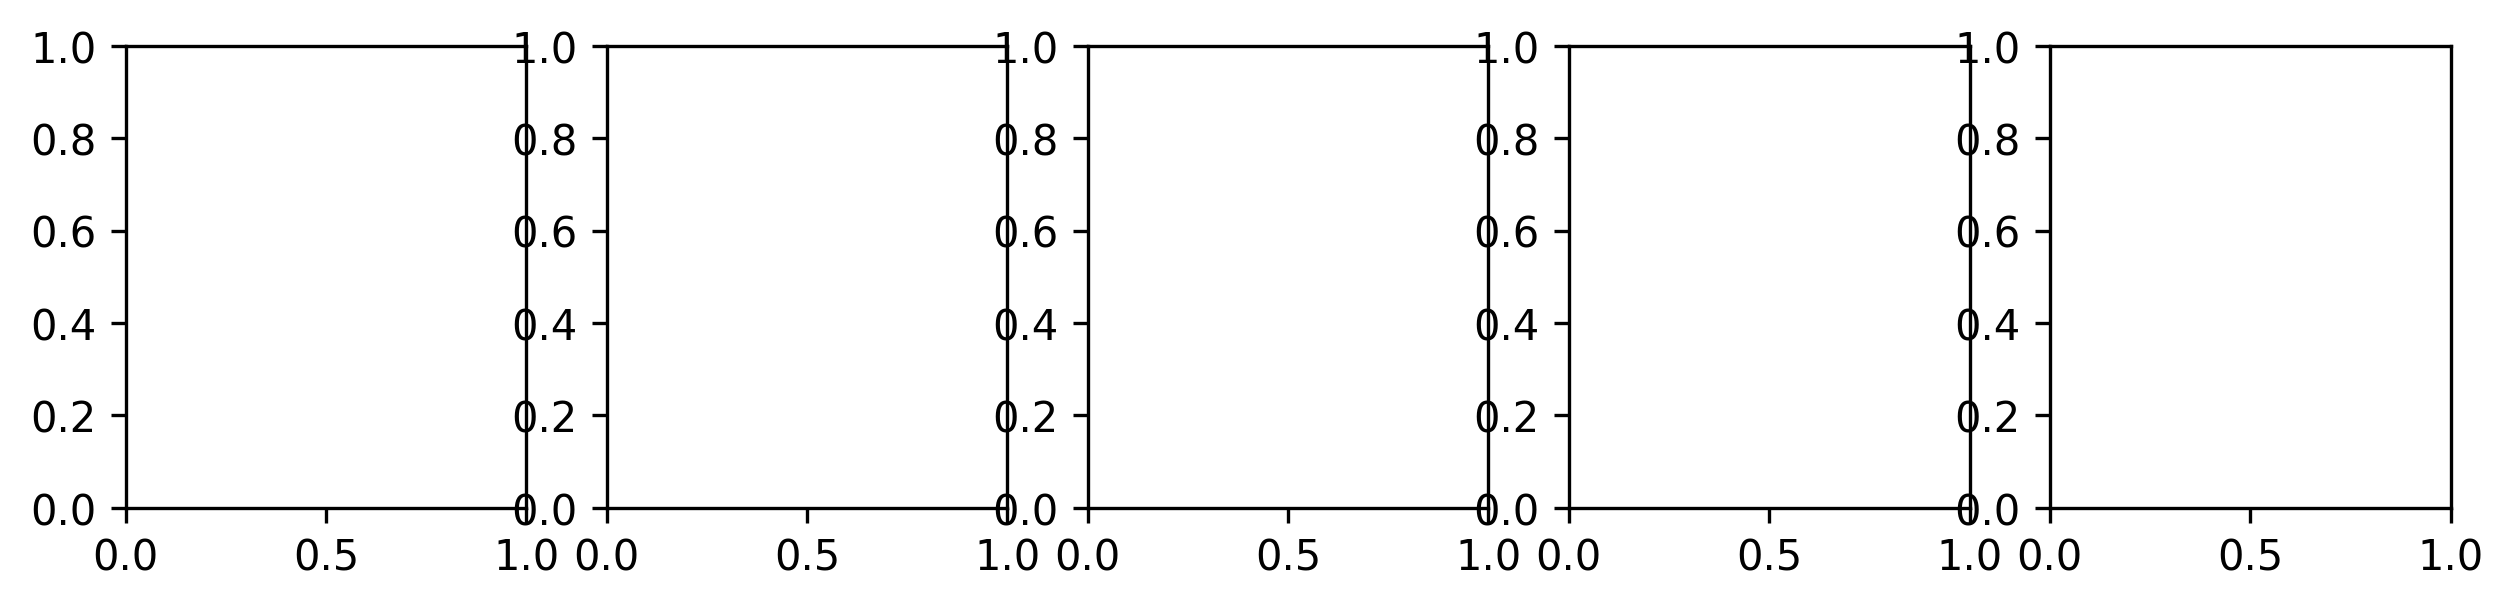

In [31]:
fn=data.feature_names
cn=data.target_names
fig, axes = plt.subplots(nrows = 1,ncols = 5,figsize = (10,2), dpi=300)
for index in range(0, 5):
    tree.plot_tree(rf.estimators_[index], feature_names = fn, class_names=cn, filled = True, ax = axes[index])

    axes[index].set_title('Tree: ' + str(index), fontsize = 10)

In [32]:
dtree = DecisionTreeClassifier(random_state=0)
dtree.fit(X_train, y_train)
pred = dtree.predict(X_test)
print('Decision tree accuracy:', accuracy_score(y_test, pred))

pred = rf.predict(X_test)
print('Random forest accuracy:', accuracy_score(y_test, pred))

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

Without fine-tuning the parameters and for this specific split of training and test subsets on this dataset, we can see an improvement in accuracy of 9% when using random forest compared to a single decision tree.

#Random Forest Regressor

##California Housing Dataset

In [33]:
data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [34]:
dtree = DecisionTreeRegressor(random_state=0)
dtree.fit(X_train, y_train)
pred = dtree.predict(X_test)
print('Decision tree mean squared error:', mean_squared_error(y_test, pred))
print('Decision tree mean absolute error:', mean_absolute_error(y_test, pred))
print('Decision tree r2 score:', r2_score(y_test, pred))

print("====================================================")

pred = rf.predict(X_test)
print('Random forest mean squared error:', mean_squared_error(y_test, pred))
print('Random forest mean absolute error:', mean_absolute_error(y_test, pred))
print('Random forest r2 score:', r2_score(y_test, pred))

Decision tree mean squared error: 0.5008492183132024
Decision tree mean absolute error: 0.4568540915697674
Decision tree r2 score: 0.617791676774418
Random forest mean squared error: 0.25494609886384606
Random forest mean absolute error: 0.32667023689437996
Random forest r2 score: 0.8054453967446964


#Neural Networks

##Breast Cancer Dataset

In [35]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Scale the features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
def create_model(input_dim):
    model = Sequential([
        # Input layer
        Dense(32, activation='relu', input_dim=input_dim),
        Dropout(0.2),  # Dropout to reduce overfitting

        # Hidden layer
        Dense(8, activation='relu'),
        Dropout(0.2),

        # Output layer - binary classification
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [38]:
model = create_model(X_train_scaled.shape[1])

C:\Users\Sandra\Downloads\Flight_Management_DNICK_2026-main\Flight_Management_DNICK_2026-main\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,265 (4.94 KB)

 Trainable params: 1,265 (4.94 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7418 - loss: 0.6031 - val_accuracy: 0.8901 - val_loss: 0.4709
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8434 - loss: 0.4897 - val_accuracy: 0.9121 - val_loss: 0.3849
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8626 - loss: 0.4108 - val_accuracy: 0.9121 - val_loss: 0.3224
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9038 - loss: 0.3303 - val_accuracy: 0.9341 - val_loss: 0.2772
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9341 - loss: 0.2915 - val_accuracy: 0.9341 - val_loss: 0.2422
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9121 - loss: 0.2808 - val_accuracy: 0.9341 - val_loss: 0.2126
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9505 - loss: 0.2135 - val_accuracy: 0.9341 - val_loss: 0.1902
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9478 - loss: 0.1995 - val_accuracy: 0.9451 - val_loss

In [41]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy: 0.9824561403508771


##California Housing Dataset

In [42]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
def create_model(input_dim):
    model = Sequential([
        # Input layer
        Dense(32, activation='relu', input_dim=input_dim),
        Dropout(0.2),

        # Hidden layers
        Dense(16, activation='relu'),
        Dropout(0.2),

        Dense(16, activation='relu'),
        Dropout(0.2),

        Dense(8, activation='relu'),

        # Output layer - no activation for regression
        Dense(1)
    ])

    # Compile model with mean squared error loss
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

In [45]:
model = create_model(X_train_scaled.shape[1])

C:\Users\Sandra\Downloads\Flight_Management_DNICK_2026-main\Flight_Management_DNICK_2026-main\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,233 (4.82 KB)

 Trainable params: 1,233 (4.82 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.8472 - mae: 0.9528 - val_loss: 0.7367 - val_mae: 0.5904
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9182 - mae: 0.6250 - val_loss: 0.6169 - val_mae: 0.5420
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6362 - mae: 0.5701 - val_loss: 0.6041 - val_mae: 0.5316
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5602 - mae: 0.5403 - val_loss: 0.6134 - val_mae: 0.5334
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5208 - mae: 0.5235 - val_loss: 0.5869 - val_mae: 0.5177
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5027 - mae: 0.5073 - val_loss: 0.5717 - val_mae: 0.5070
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4775 - mae: 0.4949 - val_loss: 0.5604 - val_mae: 0.5069
Epoch 8/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4614 - mae: 0.4908 - val_loss: 0.5990 - val_mae: 0.5191
Epoch 9/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

In [48]:
y_pred = model.predict(X_test_scaled).flatten()

print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred)}")
print(f"R² Score: {r2_score(y_test, y_pred)}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step
Mean Squared Error (MSE): 0.4292917046918906
Mean Absolute Error (MAE): 0.446834341384713
R² Score: 0.6723986848226771
